# Classical Clustering: Baseline NLP with HORUS data

This notebook implements the classical NLP clustering baseline for the project. The goal is to group scientific products into thematic clusters using traditional text mining techniques.

The pipeline follows these steps:

1. Load the preprocessed modeling dataset.
2. Select the text column prepared for classical NLP.
3. Build a TF-IDF matrix.
4. Reduce dimensionality with Latent Semantic Analysis (TruncatedSVD) to stabilize clustering.
5. Apply K-Means and Agglomerative Clustering.
6. Evaluate both models with internal clustering metrics.
7. Export labels and metrics for the comparative evaluation notebook.

# 1. Setup and imports

In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All imports successful.")

All imports successful.


### 1.1. Environment configuration

In [2]:
from google.colab import drive
drive.mount('/content/drive')
base_path = Path("/content/drive/Shareddrives/Minería/proyecto_horus/data/")
df = pd.read_parquet(base_path / "processed/products_modeling.parquet")

Mounted at /content/drive


# 2. Load dataset

This dataset already contains preprocessed columns for modeling. For the classical baseline, the most relevant column is expected to be `classical_text_for_modeling`.

In [3]:
print("Dataset shape:", df.shape)
print("Available columns:")
print(df.columns.tolist())

df.head()

Dataset shape: (99064, 16)
Available columns:
['original_title', 'original_description', 'coauthors', 'language', 'type', 'source', 'faculty', 'date', 'journal_conference', 'active_coauthors', '_extreme_coauthors', 'embeddings_text', 'tokens_ngrams', 'classic_text', '_useful_for_modeling', '_useful_for_classical_nlp']


,original_title,original_description,coauthors,language,type,source,faculty,date,journal_conference,active_coauthors,_extreme_coauthors,embeddings_text,tokens_ngrams,classic_text,_useful_for_modeling,_useful_for_classical_nlp
0,None,La producción de conocimiento a través de la i...,Gomez Villegas Mauricio,Español,Artículo de revista,RevistasUNAL,Ciencias Económicas,01/04/2015,Revista Innovar Journal,Gomez Villegas Mauricio,False,[Ciencias Económicas] Artículo de revista: La ...,"[producción_conocimiento, investigación, acadé...",producción conocimiento investigación académic...,True,True
1,None,Fruto de un proceso de interacción de más de s...,Gomez Villegas Mauricio,Español,Artículo de revista,RevistasUNAL,Ciencias Económicas,01/01/2017,Revista Innovar Journal,Gomez Villegas Mauricio,False,[Ciencias Económicas] Artículo de revista: Fru...,"[fruto, proceso, interacción, mes_diciembre, f...",fruto proceso interacción mes diciembre formal...,True,True
2,None,"Al cierre de la presente edición de INNOVAR, l...",Gomez Villegas Mauricio,Español,Artículo de revista,RevistasUNAL,Ciencias Económicas,07/04/2017,Revista Innovar Journal,Gomez Villegas Mauricio,False,[Ciencias Económicas] Artículo de revista: Al ...,"[cierre, presente_edición, innovar, ciudadanía...",cierre presente edición innovar ciudadanía lat...,True,True
3,None,Este número de INNOVAR ve la luz pública en un...,Gomez Villegas Mauricio,Español,Artículo de revista,RevistasUNAL,Ciencias Económicas,01/10/2016,Revista Innovar Journal,Gomez Villegas Mauricio,False,[Ciencias Económicas] Artículo de revista: Est...,"[número_innovar, ver_luz, público, contexto, s...",número innovar ver luz público contexto social...,True,True
4,None,"En un editorial previo de INNOVAR, se señalaro...",Gomez Villegas Mauricio,Español,Artículo de revista,RevistasUNAL,Ciencias Económicas,01/01/2015,Revista Innovar Journal,Gomez Villegas Mauricio,False,[Ciencias Económicas] Artículo de revista: En ...,"[editorial, previo, innovar, señalar, reto, ci...",editorial previo innovar señalar reto ciencia ...,True,True


### 2.1. Select rows and text column

Only records marked as useful for classical NLP are used when the `_useful_for_classical_nlp` flag is available. The text column is selected with the following priority:

1. `classical_text_for_modeling`
2. `classic_text`
3. `tokens_ngrams`
4. `embeddings_text`
5. `original_description`

The first option should be used in the current preprocessed dataset.

In [4]:
if "_useful_for_classical_nlp" in df.columns:
    df_classical = df[df["_useful_for_classical_nlp"] == True].copy()
else:
    df_classical = df.copy()

candidate_text_columns = [
    "classical_text_for_modeling",
    "classic_text",
    "tokens_ngrams",
    "embeddings_text",
    "original_description",
]

TEXT_COLUMN = None
for column in candidate_text_columns:
    if column in df_classical.columns:
        TEXT_COLUMN = column
        break

if TEXT_COLUMN is None:
    raise ValueError(f"No valid text column found. Available columns: {df_classical.columns.tolist()}")

def normalize_text(value):
    if isinstance(value, list):
        return " ".join(map(str, value))
    return str(value)

# Preserve the original row index for later merging with other notebooks.
df_classical = df_classical.copy()
df_classical["original_row_index"] = df_classical.index

df_classical["text_for_clustering"] = (
    df_classical[TEXT_COLUMN]
    .fillna("")
    .apply(normalize_text)
    .str.strip()
)

df_classical = df_classical[df_classical["text_for_clustering"].str.len() > 0].reset_index(drop=True)

texts = df_classical["text_for_clustering"]

print(f"Selected text column: {TEXT_COLUMN}")
print("Classical dataframe shape:", df_classical.shape)
texts.head()

Selected text column: classic_text
Classical dataframe shape: (99035, 18)


,text_for_clustering
0,producción conocimiento investigación académic...
1,fruto proceso interacción mes diciembre formal...
2,cierre presente edición innovar ciudadanía lat...
3,número innovar ver luz público contexto social...
4,editorial previo innovar señalar reto ciencia ...


# 3. TF-IDF representation

TF-IDF converts each document into a sparse vector that gives more weight to terms that are frequent in a document but not too common across the whole corpus.

`max_features=3000` keeps the representation manageable for clustering while retaining the most informative vocabulary.

In [5]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.90,
    sublinear_tf=True,
    norm="l2"
)

tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Vocabulary size:", len(feature_names))

TF-IDF matrix shape: (99035, 3000)
Vocabulary size: 3000


### 3.1. Latent Semantic Analysis for stable clustering

Sparse TF-IDF matrices can make K-Means inertia curves noisy because the space is very high-dimensional. To make the classical clustering baseline more stable and feasible for hierarchical clustering, TF-IDF is reduced with TruncatedSVD, also known as Latent Semantic Analysis (LSA).

This is still a classical NLP approach: it uses TF-IDF term weighting plus matrix factorization, not neural embeddings.

In [6]:
n_samples, n_features = tfidf_matrix.shape
N_COMPONENTS = min(100, n_features - 1, n_samples - 1)

if N_COMPONENTS < 2:
    raise ValueError("Not enough samples or features to perform dimensionality reduction.")

lsa_model = make_pipeline(
    TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE),
    Normalizer(copy=False)
)

lsa_matrix = lsa_model.fit_transform(tfidf_matrix)

explained_variance = lsa_model.named_steps["truncatedsvd"].explained_variance_ratio_.sum()

print("LSA matrix shape:", lsa_matrix.shape)
print(f"Explained variance ratio: {explained_variance:.4f}")

LSA matrix shape: (99035, 100)
Explained variance ratio: 0.1842


# 4. K-Means clustering

K-Means is used as the main classical baseline. Since the number of clusters is not known in advance, the elbow method is used as a practical heuristic.

### 4.1. Elbow method

The elbow method evaluates the K-Means inertia for different values of `k`. A good value is usually near the point where the curve stops decreasing sharply.

The curve is computed on the LSA representation to avoid the noisy behavior often observed when K-Means is applied directly over sparse high-dimensional TF-IDF.

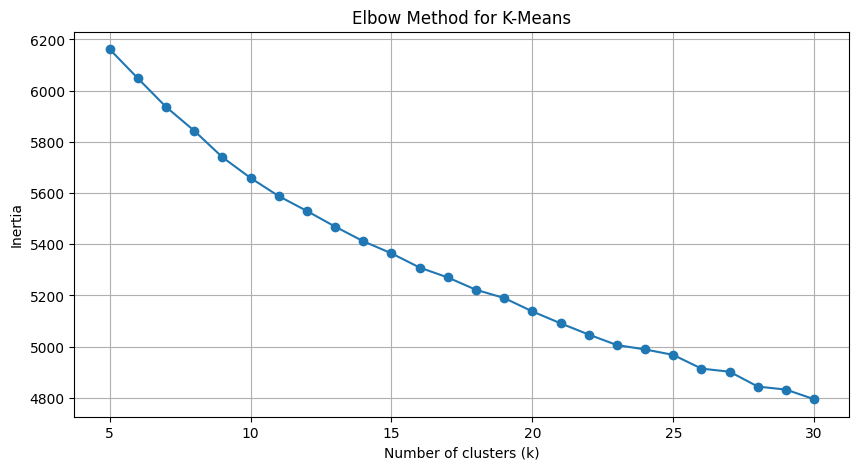

,k,inertia
0,5,6161.939603
1,6,6048.420080
2,7,5936.618990
3,8,5843.589231
4,9,5740.126739
5,10,5659.014507
6,11,5588.030372
7,12,5529.995092
8,13,5468.929339
9,14,5411.741696


In [7]:
K_RANGE = range(5, 31)
MAX_ELBOW_SAMPLE_SIZE = min(8000, lsa_matrix.shape[0])

rng = np.random.default_rng(RANDOM_STATE)
if lsa_matrix.shape[0] > MAX_ELBOW_SAMPLE_SIZE:
    elbow_indices = rng.choice(lsa_matrix.shape[0], size=MAX_ELBOW_SAMPLE_SIZE, replace=False)
    elbow_matrix = lsa_matrix[elbow_indices]
else:
    elbow_matrix = lsa_matrix

inertias = []
for k in K_RANGE:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=50,
        max_iter=500,
        random_state=RANDOM_STATE
    )
    kmeans.fit(elbow_matrix)
    inertias.append(kmeans.inertia_)

elbow_results = pd.DataFrame({
    "k": list(K_RANGE),
    "inertia": inertias
})

plt.figure(figsize=(10, 5))
plt.plot(elbow_results["k"], elbow_results["inertia"], marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

elbow_results

### 4.2. Automatic elbow suggestion

The following helper estimates the elbow by finding the point with the largest distance to the line joining the first and last points of the inertia curve. The final value can still be adjusted manually after inspecting the plot.

In [8]:
def suggest_elbow_k(k_values, inertia_values):
    points = np.column_stack([np.array(k_values, dtype=float), np.array(inertia_values, dtype=float)])
    first_point = points[0]
    last_point = points[-1]
    line_vector = last_point - first_point
    line_length = np.linalg.norm(line_vector)

    if line_length == 0:
        return int(k_values[0])

    distances = np.abs(np.cross(line_vector, first_point - points)) / line_length
    elbow_index = int(np.argmax(distances))
    return int(k_values[elbow_index])

ELBOW_K = suggest_elbow_k(list(K_RANGE), inertias)

print(f"Suggested k according to the elbow heuristic: {ELBOW_K}")

Suggested k according to the elbow heuristic: 14


/tmp/ipykernel_2236/165444724.py:11: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances = np.abs(np.cross(line_vector, first_point - points)) / line_length


### 4.3. Select final K

The selected value of `k` will also be useful for the modern clustering notebook, because the embedding-based K-Means model should use the same number of clusters for a fair comparison.

If the elbow is not clear, keep a medium value that balances interpretability and topic granularity. The automatic suggestion is used by default, but it can be changed manually.

In [9]:
SELECTED_K = ELBOW_K

# Uncomment and edit this line if the team decides to use a fixed shared value.
# SELECTED_K = 12

print(f"Selected number of clusters: {SELECTED_K}")

Selected number of clusters: 14


### 4.4. Fit final K-Means model

In [10]:
kmeans_model = KMeans(
    n_clusters=SELECTED_K,
    init="k-means++",
    n_init=50,
    max_iter=500,
    random_state=RANDOM_STATE
)

kmeans_labels = kmeans_model.fit_predict(lsa_matrix)

df_classical["cluster_classical_kmeans"] = kmeans_labels

print("K-Means labels generated:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means labels generated:
0     14367
1      6763
2      5351
3     24076
4      2981
5      2108
6      3822
7      6503
8      5876
9      6205
10     9352
11     2891
12     3848
13     4892
Name: count, dtype: int64


### 4.5. Inspect top terms by K-Means cluster

To interpret the clusters, the average TF-IDF weight is computed for each K-Means group. The highest-weighted terms are used as a descriptive approximation of the cluster topic.

In [11]:
def get_top_terms_by_cluster(tfidf_data, labels, feature_names, top_n=10):
    rows = []
    labels = np.array(labels)

    for cluster_id in sorted(np.unique(labels)):
        cluster_mask = labels == cluster_id
        cluster_tfidf = tfidf_data[cluster_mask]
        mean_tfidf = np.asarray(cluster_tfidf.mean(axis=0)).ravel()
        top_indices = mean_tfidf.argsort()[::-1][:top_n]
        top_terms = feature_names[top_indices].tolist()
        rows.append({
            "cluster": int(cluster_id),
            "size": int(cluster_mask.sum()),
            "top_terms": ", ".join(top_terms)
        })

    return pd.DataFrame(rows)

kmeans_top_terms = get_top_terms_by_cluster(
    tfidf_matrix,
    kmeans_labels,
    feature_names,
    top_n=12
)

kmeans_top_terms

,cluster,size,top_terms
0,0,14367,"investigación, social, proceso, colombia, él, ..."
1,1,6763,"modelo, sistema, dato, utilizar, permitir, pre..."
2,2,5351,"health, development, colombia, result, process..."
3,3,24076,"colombiano, sistema, salud, ciencia, desarroll..."
4,4,2981,"cell, protein, gene, peptide, expression, acti..."
5,5,2108,"decay, collision, tev, mass, detector, proton,..."
6,6,3822,"colombia, nacional, universidad, especie, bogo..."
7,7,6503,"high, temperature, effect, water, obtain, prop..."
8,8,5876,"model, system, propose, base, result, datum, a..."
9,9,6205,"paciente, clínico, enfermedad, diagnóstico, tr..."


# 5. Agglomerative Clustering

Agglomerative Clustering is the second classical algorithm. This model can be expensive with many rows, so it is run on a reproducible sample when the dataset is large.

The same LSA representation and the same selected number of clusters are used to make it comparable with K-Means.

In [12]:
MAX_AGGLOMERATIVE_SAMPLE_SIZE = min(5000, lsa_matrix.shape[0])

rng = np.random.default_rng(RANDOM_STATE)
if lsa_matrix.shape[0] > MAX_AGGLOMERATIVE_SAMPLE_SIZE:
    agglomerative_indices = rng.choice(
        lsa_matrix.shape[0],
        size=MAX_AGGLOMERATIVE_SAMPLE_SIZE,
        replace=False
    )
else:
    agglomerative_indices = np.arange(lsa_matrix.shape[0])

agglomerative_matrix = lsa_matrix[agglomerative_indices]

agglomerative_model = AgglomerativeClustering(
    n_clusters=SELECTED_K,
    linkage="ward"
)

agglomerative_labels_sample = agglomerative_model.fit_predict(agglomerative_matrix)

# Store labels only for the sampled rows. Non-sampled rows remain missing by design.
df_classical["cluster_classical_agglomerative"] = pd.NA
df_classical.loc[agglomerative_indices, "cluster_classical_agglomerative"] = agglomerative_labels_sample

print("Agglomerative sample size:", len(agglomerative_indices))
print("Agglomerative labels generated on sample:")
print(pd.Series(agglomerative_labels_sample).value_counts().sort_index())

Agglomerative sample size: 5000
Agglomerative labels generated on sample:
0     727
1     856
2     508
3     406
4     505
5     438
6     503
7      79
8     107
9     221
10    197
11    101
12    260
13     92
Name: count, dtype: int64


### 5.1. Inspect top terms by Agglomerative cluster

In [13]:
agglomerative_top_terms = get_top_terms_by_cluster(
    tfidf_matrix[agglomerative_indices],
    agglomerative_labels_sample,
    feature_names,
    top_n=12
)

agglomerative_top_terms

,cluster,size,top_terms
0,0,727,"sistema, colombia, especie, diseño, nacional, ..."
1,1,856,"colombiano, social, efecto, revista, colombia,..."
2,2,508,"derecho, desarrollo, colombia, siglo, proceso,..."
3,3,406,"effect, temperature, material, property, obtai..."
4,4,505,"model, system, result, base, propose, differen..."
5,5,438,"modelo, propiedad, ecuación, permitir, sistema..."
6,6,503,"paciente, salud, enfermedad, tratamiento, año,..."
7,7,79,"colombia, uso, páramo, marta, record, justicia..."
8,8,107,"decay, collision, tev, mass, detector, proton,..."
9,9,221,"specie, new, america, colombian, latin, popula..."


# 6. Internal evaluation

Internal metrics evaluate the compactness and separation of the clusters without using external labels.

Metrics included:

- **Silhouette Score:** higher is better.
- **Calinski-Harabasz Score:** higher is better.
- **Davies-Bouldin Score:** lower is better.

For efficiency and comparability, K-Means is evaluated on the same sample used for the Agglomerative model when possible.

In [14]:
def safe_internal_metrics(matrix, labels, model_name):
    labels = np.array(labels)
    unique_labels = np.unique(labels)

    if len(unique_labels) < 2:
        return {
            "model": model_name,
            "n_samples": matrix.shape[0],
            "n_clusters": len(unique_labels),
            "silhouette_score": np.nan,
            "calinski_harabasz_score": np.nan,
            "davies_bouldin_score": np.nan,
        }

    return {
        "model": model_name,
        "n_samples": matrix.shape[0],
        "n_clusters": len(unique_labels),
        "silhouette_score": silhouette_score(matrix, labels, metric="euclidean"),
        "calinski_harabasz_score": calinski_harabasz_score(matrix, labels),
        "davies_bouldin_score": davies_bouldin_score(matrix, labels),
    }

kmeans_labels_on_sample = kmeans_labels[agglomerative_indices]

metrics_results = pd.DataFrame([
    safe_internal_metrics(agglomerative_matrix, kmeans_labels_on_sample, "K-Means + TF-IDF/LSA"),
    safe_internal_metrics(agglomerative_matrix, agglomerative_labels_sample, "Agglomerative + TF-IDF/LSA"),
])

metrics_results

,model,n_samples,n_clusters,silhouette_score,calinski_harabasz_score,davies_bouldin_score
0,K-Means + TF-IDF/LSA,5000,14,0.075878,123.642493,2.889934
1,Agglomerative + TF-IDF/LSA,5000,14,0.052116,102.101750,3.377709


# 7. Export results

The outputs are saved in the shared Drive folder under `proyecto_horus/outputs/`. These files can be used later by the comparative evaluation notebook.



In [15]:
PROJECT_DIR = base_path.parent
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

labels_output_path = OUTPUT_DIR / "04_classical_clustering_labels.parquet"
metrics_output_path = OUTPUT_DIR / "04_classical_clustering_metrics.csv"
top_terms_kmeans_path = OUTPUT_DIR / "04_classical_kmeans_top_terms.csv"
top_terms_agglomerative_path = OUTPUT_DIR / "04_classical_agglomerative_top_terms.csv"
elbow_output_path = OUTPUT_DIR / "04_classical_elbow_results.csv"

export_columns = [
    "original_row_index",
    "cluster_classical_kmeans",
    "cluster_classical_agglomerative",
]

for optional_column in ["original_title", "faculty", "type", "source", "date"]:
    if optional_column in df_classical.columns:
        export_columns.append(optional_column)

labels_output = df_classical[export_columns].copy()

labels_output.to_parquet(labels_output_path, index=False)
metrics_results.to_csv(metrics_output_path, index=False)
kmeans_top_terms.to_csv(top_terms_kmeans_path, index=False)
agglomerative_top_terms.to_csv(top_terms_agglomerative_path, index=False)
elbow_results.to_csv(elbow_output_path, index=False)

print("Saved files in shared Drive:")
print(labels_output_path)
print(metrics_output_path)
print(top_terms_kmeans_path)
print(top_terms_agglomerative_path)
print(elbow_output_path)


Saved files in shared Drive:
/content/drive/Shareddrives/Minería/proyecto_horus/outputs/04_classical_clustering_labels.parquet
/content/drive/Shareddrives/Minería/proyecto_horus/outputs/04_classical_clustering_metrics.csv
/content/drive/Shareddrives/Minería/proyecto_horus/outputs/04_classical_kmeans_top_terms.csv
/content/drive/Shareddrives/Minería/proyecto_horus/outputs/04_classical_agglomerative_top_terms.csv
/content/drive/Shareddrives/Minería/proyecto_horus/outputs/04_classical_elbow_results.csv


# 8. Brief interpretation

The classical baseline was built using TF-IDF and Latent Semantic Analysis. K-Means was selected as the main model because it can assign labels to the complete dataset, while Agglomerative Clustering was used as a second classical approach on a reproducible sample due to its higher computational cost.

The elbow method was used to choose the number of clusters. If the elbow was not perfectly sharp, this is expected in high-dimensional text data. The selected value of `k` balances interpretability and granularity, and should be shared with the modern clustering notebook so that its K-Means model uses the same number of groups.

The top terms per cluster provide an initial human-readable interpretation of the topics discovered by the classical approach. These labels and metrics are exported so that the evaluator can compare them against the modern embedding-based approach and external variables such as faculty.